# 🗺️ EDA: Геройская VRPTW — Изучаем карту приключений

Цель: понять распределение мельниц, героев и расстояний, прежде чем строить маршруты.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA = Path('/Users/dmitrii/Desktop/archive')  # adjust if needed

## 1. Загрузка данных

In [5]:
heroes   = pd.read_csv(DATA / 'data_heroes.csv')
objects  = pd.read_csv(DATA / 'data_objects.csv')
dist_s   = pd.read_csv(DATA / 'dist_start.csv')
dist_obj = pd.read_csv(DATA / 'dist_objects.csv', index_col=0)

print('Heroes :', heroes.shape)
print('Objects:', objects.shape)
print('dist_start:', dist_s.shape)
print('dist_objects:', dist_obj.shape)

Heroes : (100, 2)
Objects: (700, 3)
dist_start: (700, 2)
dist_objects: (700, 699)


## 2. Герои: распределение move_points

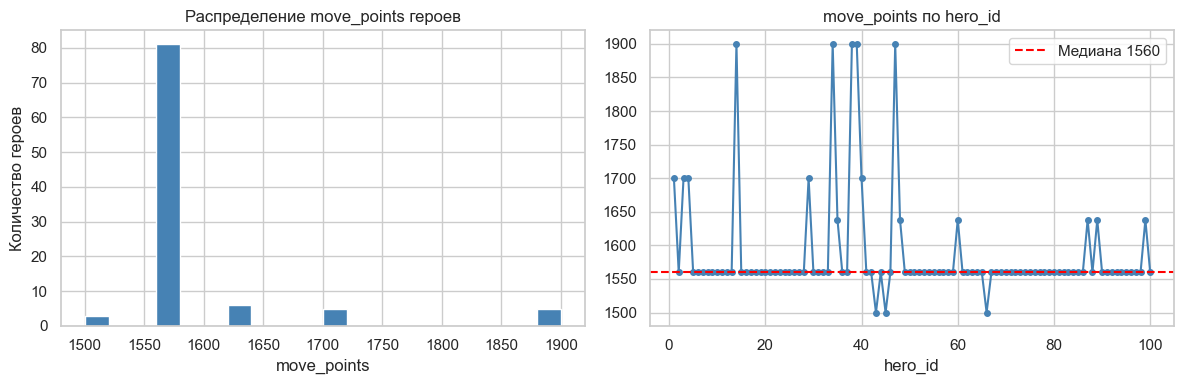

count     100.000000
mean     1586.880000
std        81.094194
min      1500.000000
25%      1560.000000
50%      1560.000000
75%      1560.000000
max      1900.000000
Name: move_points, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

heroes['move_points'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Распределение move_points героев')
axes[0].set_xlabel('move_points')
axes[0].set_ylabel('Количество героев')

axes[1].plot(heroes['hero_id'], heroes['move_points'], 'o-', ms=4, color='steelblue')
axes[1].axhline(heroes['move_points'].median(), color='red', linestyle='--', label=f"Медиана {heroes['move_points'].median():.0f}")
axes[1].set_title('move_points по hero_id')
axes[1].set_xlabel('hero_id')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_heroes.png', dpi=150)
plt.show()
print(heroes['move_points'].describe())

## 3. Мельницы: распределение по дням и наградам

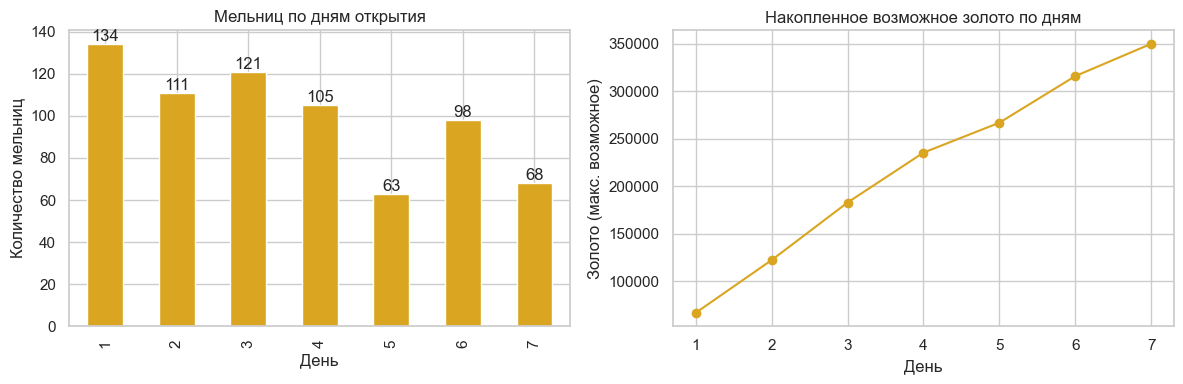

Всего потенциального золота: 350,000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

day_counts = objects['day_open'].value_counts().sort_index()
day_counts.plot(kind='bar', ax=axes[0], color='goldenrod', edgecolor='white')
axes[0].set_title('Мельниц по дням открытия')
axes[0].set_xlabel('День')
axes[0].set_ylabel('Количество мельниц')
axes[0].bar_label(axes[0].containers[0])

# Cumulative gold available
cum_gold = (day_counts * 500).cumsum()
cum_gold.plot(ax=axes[1], marker='o', color='goldenrod')
axes[1].set_title('Накопленное возможное золото по дням')
axes[1].set_xlabel('День')
axes[1].set_ylabel('Золото (макс. возможное)')

plt.tight_layout()
plt.savefig('eda_objects.png', dpi=150)
plt.show()
print(f'Всего потенциального золота: {objects["reward"].sum():,}')

## 4. Расстояния от замка

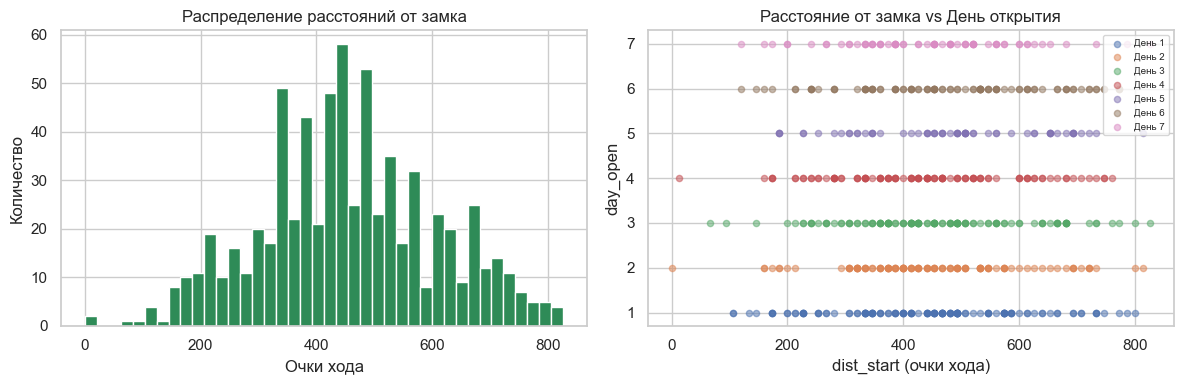

count    700.000000
mean     454.675714
std      153.150535
min        0.000000
25%      346.000000
50%      453.000000
75%      549.500000
max      826.000000
Name: dist_start, dtype: float64


In [8]:
df = objects.merge(dist_s, on='object_id')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['dist_start'].hist(bins=40, ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('Распределение расстояний от замка')
axes[0].set_xlabel('Очки хода')
axes[0].set_ylabel('Количество')

for day, grp in df.groupby('day_open'):
    axes[1].scatter(grp['dist_start'], [day]*len(grp), alpha=0.5, s=20, label=f'День {day}')
axes[1].set_title('Расстояние от замка vs День открытия')
axes[1].set_xlabel('dist_start (очки хода)')
axes[1].set_ylabel('day_open')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('eda_distances.png', dpi=150)
plt.show()
print(df['dist_start'].describe())

## 5. Достижимость мельниц за 1 день

In [9]:
VISIT_COST = 100
HERO_SPEEDS = heroes['move_points'].values

# For each object: how many heroes can reach it on day 1 (from castle)?
# A hero with mp can visit if dist_start + visit_cost <= mp (last-move rule: >= 1 mp after dist_start)
reachable_d1 = {}
for _, row in df.iterrows():
    if row['day_open'] == 1:
        cost = row['dist_start']  # last-move: 1 mp needed after travel
        n_heroes = (HERO_SPEEDS >= cost).sum()
        reachable_d1[row['object_id']] = n_heroes

reachable_series = pd.Series(reachable_d1)
print(f"Мельниц в день 1: {len(reachable_d1)}")
print(f"Из них достижимы хотя бы 1 героем: {(reachable_series > 0).sum()}")
print(f"Максимально удалённая (от замка) мельница дня 1: {df[df.day_open==1]['dist_start'].max()} очков хода")
print(f"Самый быстрый герой: {HERO_SPEEDS.max()} очков хода")

Мельниц в день 1: 134
Из них достижимы хотя бы 1 героем: 134
Максимально удалённая (от замка) мельница дня 1: 800 очков хода
Самый быстрый герой: 1900 очков хода


## 6. Ключевые выводы EDA

| Параметр | Значение |
|---|---|
| Всего мельниц | 700 |
| Потенциальное золото (700 × 500) | 350,000 |
| Стоимость всех 100 героев (100 × 2500) | 250,000 |
| Героев нужно нанять для hero_id=N | N |
| visit_cost | 100 |
| Недель | 1 (7 дней) |

**Ключевой вопрос**: при каком числе героев выгода от собранного золота перекрывает затраты на найм?

Если 1 герой собирает в среднем ≥ 5 мельниц ⇒ `5 × 500 = 2500` ≥ `hero_cost`. Значит каждый дополнительный герой окупается при 5+ успешных посещениях.